### Imports

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import sys
import os
import torch
import copy

sys.path.insert(0, os.path.dirname(os.getcwd()))

### Configuration

In [2]:
PROFILE = {
    "DoE_Gesamt_RhodaminB": [25,9],
    "DoE_Gesamt_4MU": [13,19,12]
}
INTERPOLATION_OPTIONS = ["linear", "cubic"]
FILENAMES = ["DoE_Gesamt_4MU", "DoE_Gesamt_RhodaminB"]
FILENAME = FILENAMES[0]
INTERPOLATION = INTERPOLATION_OPTIONS[0]

### Read Data

In [3]:
from src.bay_op_projekt.helper import load_data_to_df
path = Path(f"../data/{FILENAME}.csv")
parameter_names = ["Temperatur", "pH"]
target_names = ["Lipase_Aktivität_1", "Lipase_Aktivität_2", "Lipase_Aktivität_3"] # The mean of these rows is used in further calculations.
df, train_X_raw, train_Y_raw = load_data_to_df(path=path, parameter_row_names=parameter_names,target_row_names=target_names, profile=PROFILE[FILENAME])


### Normalise Data

In [4]:
from src.bay_op_projekt.normalisation import normalize, standardize_Y

bounds_raw = torch.tensor([
    [8.0, 5.0],   # [min_Temperatur, min_pH]
    [33.0, 8.5]   # [max_Temperatur, max_pH]
])

train_X = normalize(copy.deepcopy(train_X_raw), bounds_raw)
train_Y, Y_mean, Y_std = standardize_Y(train_Y_raw)
train_Yvar = torch.tensor(train_Y_raw / Y_std.item()**2, dtype=torch.double).reshape(-1, 1)
bounds_normalized = torch.zeros(2, 2, dtype=torch.double)
bounds_normalized[1] = 1.0

### Modeltraining

In [5]:
from src.bay_op_projekt.model_training import train_gp_model

model = train_gp_model(train_X, train_Y, train_Yvar)


### Extract the Recomendations from the model.

In [6]:
from botorch.acquisition import qLogExpectedImprovement
from botorch.optim import optimize_acqf
best_f = train_Y.max()

acq_function = qLogExpectedImprovement(model=model, best_f=best_f)

candidate_normalized, acq_value = optimize_acqf(
    acq_function=acq_function,
    bounds=bounds_normalized,
    q=3,
    num_restarts=30,
    raw_samples=512,
)
candidate_raw = candidate_normalized * (bounds_raw[1] - bounds_raw[0]) + bounds_raw[0]
print(f"\n➡ Nächstes Experiment vorgeschlagen:")
for i in range(3):
    print(f"   Kandidat {i+1}:")
    print(f"   Temperatur: {candidate_raw[i, 0].item():.2f} °C")
    print(f"   pH-Wert:    {candidate_raw[i, 1].item():.3f}")


➡ Nächstes Experiment vorgeschlagen:
   Kandidat 1:
   Temperatur: 26.59 °C
   pH-Wert:    8.500
   Kandidat 2:
   Temperatur: 24.64 °C
   pH-Wert:    8.500
   Kandidat 3:
   Temperatur: 26.61 °C
   pH-Wert:    5.000


### Visualisation

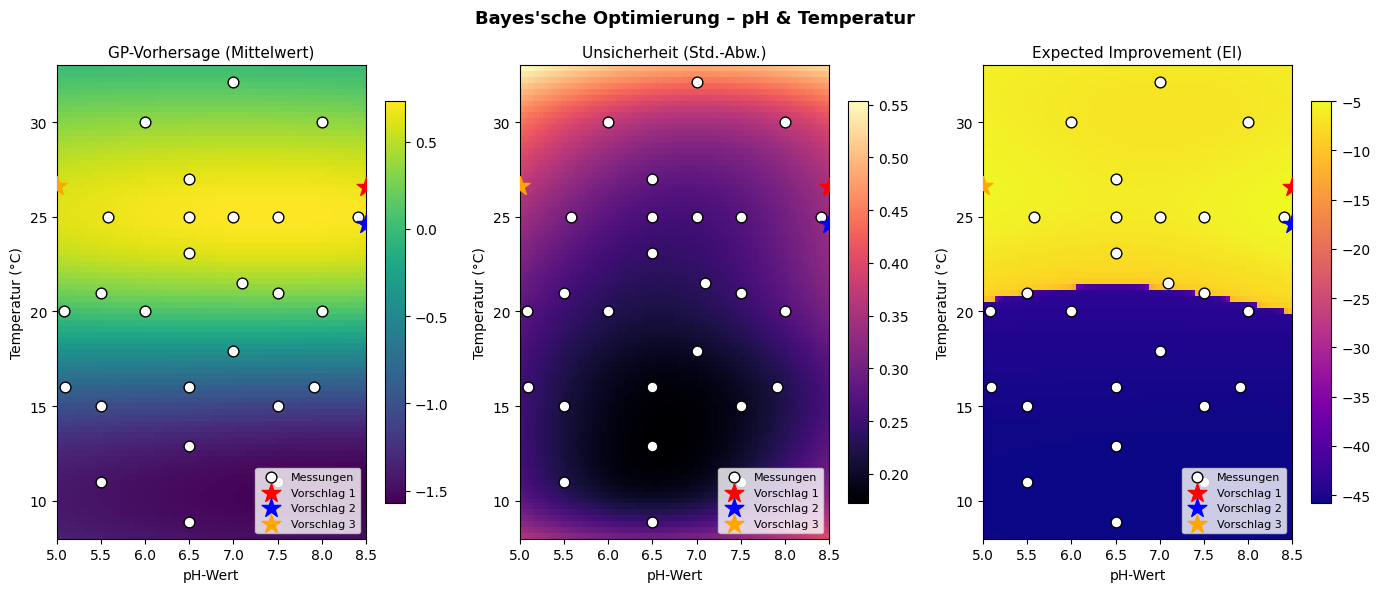

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

# Auflösung des Grids
res = 80
temp_vals = torch.linspace(0, 1, res, dtype=torch.double)
ph_vals   = torch.linspace(0, 1, res, dtype=torch.double)
grid_T, grid_pH = torch.meshgrid(temp_vals, ph_vals, indexing='ij')
grid_points = torch.stack([grid_T.flatten(), grid_pH.flatten()], dim=1)

# GP-Vorhersagen
with torch.no_grad():
    posterior = model.posterior(grid_points)
    mean    = posterior.mean.reshape(res, res).numpy()
    std_dev = posterior.variance.sqrt().reshape(res, res).numpy()

# EI auf dem Grid berechnen
with torch.no_grad():
    ei_vals = acq_function(grid_points.unsqueeze(1))
    ei_map  = ei_vals.reshape(res, res).numpy()

# Rückrechnung der Achsen auf echte Einheiten
temp_axis = np.linspace(bounds_raw[0, 0].item(), bounds_raw[1, 0].item(), res)
ph_axis   = np.linspace(bounds_raw[0, 1].item(), bounds_raw[1, 1].item(), res)

fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle("Bayes'sche Optimierung – pH & Temperatur", fontsize=13, fontweight='bold')

# Gemeinsame Plot-Hilfsfunktion mit vertauschten Achsen
def plot_heatmap(ax, data, title, cmap, xlabel=True):
    im = ax.imshow(
        data.T,
        origin='lower',
        aspect='auto',
        cmap=cmap,
        extent=[ph_axis[0], ph_axis[-1], temp_axis[0], temp_axis[-1]]
    )

    plt.colorbar(im, ax=ax, shrink=0.85)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("pH-Wert")
    ax.set_ylabel("Temperatur (°C)")

    # Bisherige Experimente einzeichnen
    X_real = copy.deepcopy(train_X_raw)

    ax.scatter(
        X_real[:, 1],   # pH -> x
        X_real[:, 0],   # Temperatur -> y
        c='white',
        edgecolors='black',
        s=60,
        zorder=5,
        label='Messungen'
    )

    # Nächste Vorschläge
    ax.scatter(
        candidate_raw[0, 1].item(),  # pH
        candidate_raw[0, 0].item(),  # Temperatur
        c='red',
        marker='*',
        s=200,
        zorder=6,
        label='Vorschlag 1'
    )

    ax.scatter(
        candidate_raw[1, 1].item(),
        candidate_raw[1, 0].item(),
        c='blue',
        marker='*',
        s=200,
        zorder=6,
        label='Vorschlag 2'
    )

    ax.scatter(
        candidate_raw[2, 1].item(),
        candidate_raw[2, 0].item(),
        c='orange',
        marker='*',
        s=200,
        zorder=6,
        label='Vorschlag 3'
    )

    ax.legend(fontsize=8, loc='lower right')

# Daten für die Plots müssen transponiert werden für korrekte Darstellung
plot_heatmap(axes[0], mean.T,    "GP-Vorhersage (Mittelwert)", 'viridis')
plot_heatmap(axes[1], std_dev.T, "Unsicherheit (Std.-Abw.)",   'magma')
plot_heatmap(axes[2], ei_map.T,  "Expected Improvement (EI)",  'plasma')

plt.tight_layout()
Path(f"../plots/{FILENAME}").mkdir(parents=True, exist_ok=True)
plt.savefig(f"../plots/{FILENAME}/bayes_opt_heatmaps.png", dpi=150, bbox_inches='tight')
plt.show()


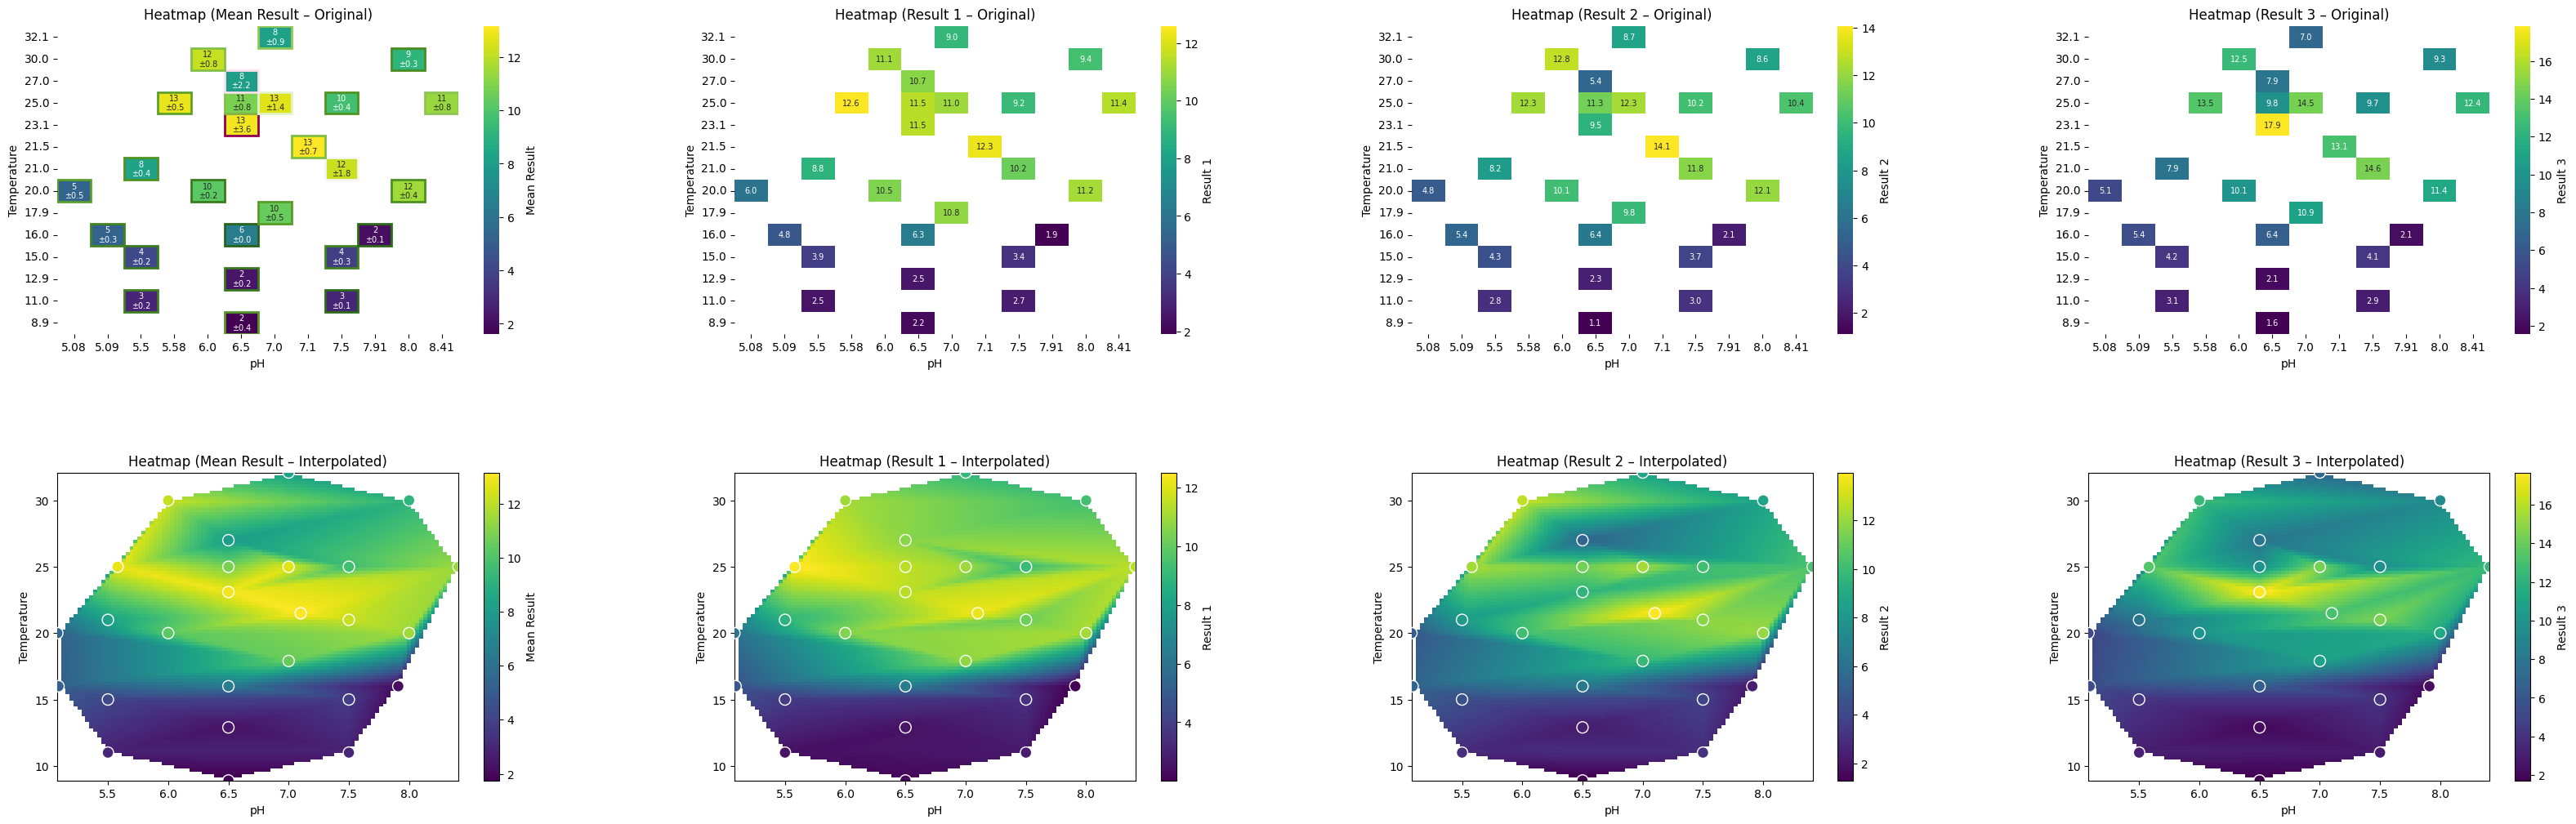

In [8]:
%matplotlib inline
from matplotlib.patches import Rectangle
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import pandas as pd

ph_values = train_X_raw[:, 1]
temperatures_values = train_X_raw[:, 0]
result = df["target"]
Y_std_np = df["Y_std"]

x = np.linspace(ph_values.min(),           ph_values.max(),           100)
y = np.linspace(temperatures_values.min(), temperatures_values.max(), 100)
X, Y = np.meshgrid(x, y)

means = [np.mean(v) for v in result]
r1    = [v[0] for v in result]
r2    = [v[1] for v in result]
r3    = [v[2] for v in result]

points = (ph_values, temperatures_values)
Z_grids = [
    griddata(points, vals, (X, Y), method=INTERPOLATION)
    for vals in (means, r1, r2, r3)
]

if True:
    Z_nearest=[griddata(points, vals, (X, Y), method='nearest')
    for vals in (means, r1, r2, r3)]
    Z = np.where(np.isnan(Z_grids), Z_nearest, Z_grids)

df = pd.DataFrame({
    'Temperature': temperatures_values,
    'pH':          ph_values,
    'Mean':        means,
    'Result_1':    r1,
    'Result_2':    r2,
    'Result_3':    r3,
    'Y_std_np':    Y_std_np
})

value_cols = ['Mean', 'Result_1', 'Result_2', 'Result_3']
zlabels    = ['Mean Result', 'Result 1', 'Result 2', 'Result 3']

pivots = [
    df.pivot_table(index='Temperature', columns='pH', values=col, aggfunc='first')
    for col in value_cols
]
std_pivot = df.pivot_table(index='Temperature', columns='pH', values="Y_std_np", aggfunc='first')


# ── Figure: 2 Zeilen × 4 Spalten ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(40, 12))
fig.subplots_adjust(hspace=0.45, wspace=0.35)

for i, (Z, pivot, zlabel) in enumerate(zip(Z_grids, pivots, zlabels)):

    # Zeile 1: Original (nicht-interpoliert)
    ax = axes[0, i]
    annot = True

    if i == 0:
        annot = np.empty(pivot.shape, dtype=object)
        for r in range(pivot.shape[0]):
            for c in range(pivot.shape[1]):
                value = pivot.iloc[r, c]
                std = std_pivot.iloc[r, c]
                if np.isnan(value):
                    annot[r, c] = ""
                else:
                    annot[r, c] = f"{value:.0f}\n±{std:.1f}"

    # Heatmap mit Rahmen
    ax = sns.heatmap(
        pivot, cmap='viridis', annot=annot, fmt=('' if i == 0 else '.1f'),
        cbar_kws={'label': zlabel}, ax=ax, annot_kws={'size': 7},
    )

    if i==0:
        std_norm = (std_pivot - std_pivot.min().min()) / (std_pivot.max().max() - std_pivot.min().min())
        std_cmap = plt.cm.PiYG_r

        for r in range(pivot.shape[0]):
            for c in range(pivot.shape[1]):
                if not np.isnan(std_pivot.iloc[r, c]):
                    std_val = std_norm.iloc[r, c]
                    color = std_cmap(std_val)

                    rect = Rectangle(
                        (c, r), 1, 1,
                        fill=False,
                        edgecolor=color,
                        linewidth=2
                    )
                    ax.add_patch(rect)

    ax.invert_yaxis()
    ax.set_title(f'Heatmap ({zlabel} – Original)', fontsize=12)
    ax.set_xlabel('pH', fontsize=10)
    ax.set_ylabel('Temperature', fontsize=10)




    # Zeile 2: Interpoliert
    ax = axes[1, i]
    im = ax.imshow(
        Z,
        extent=[ph_values.min(), ph_values.max(),
                temperatures_values.min(), temperatures_values.max()],
        origin='lower',
        cmap='viridis',
        aspect='auto',
    )
    sc = ax.scatter(
        ph_values,
        temperatures_values,
        c=df[value_cols[i]],
        cmap='viridis',
        edgecolors='white',
        linewidths=1,
        s=100,
        zorder=10
    )

    ax.set_title(f'Heatmap ({zlabel} – Interpolated)', fontsize=12)
    ax.set_xlabel('pH',          fontsize=10)
    ax.set_ylabel('Temperature', fontsize=10)
    plt.colorbar(im, ax=ax, label=zlabel)

Path(f"../plots/{FILENAME}").mkdir(parents=True, exist_ok=True)
plt.savefig(f"../plots/{FILENAME}/data_heatmaps.png", dpi=150, bbox_inches='tight')
plt.show()

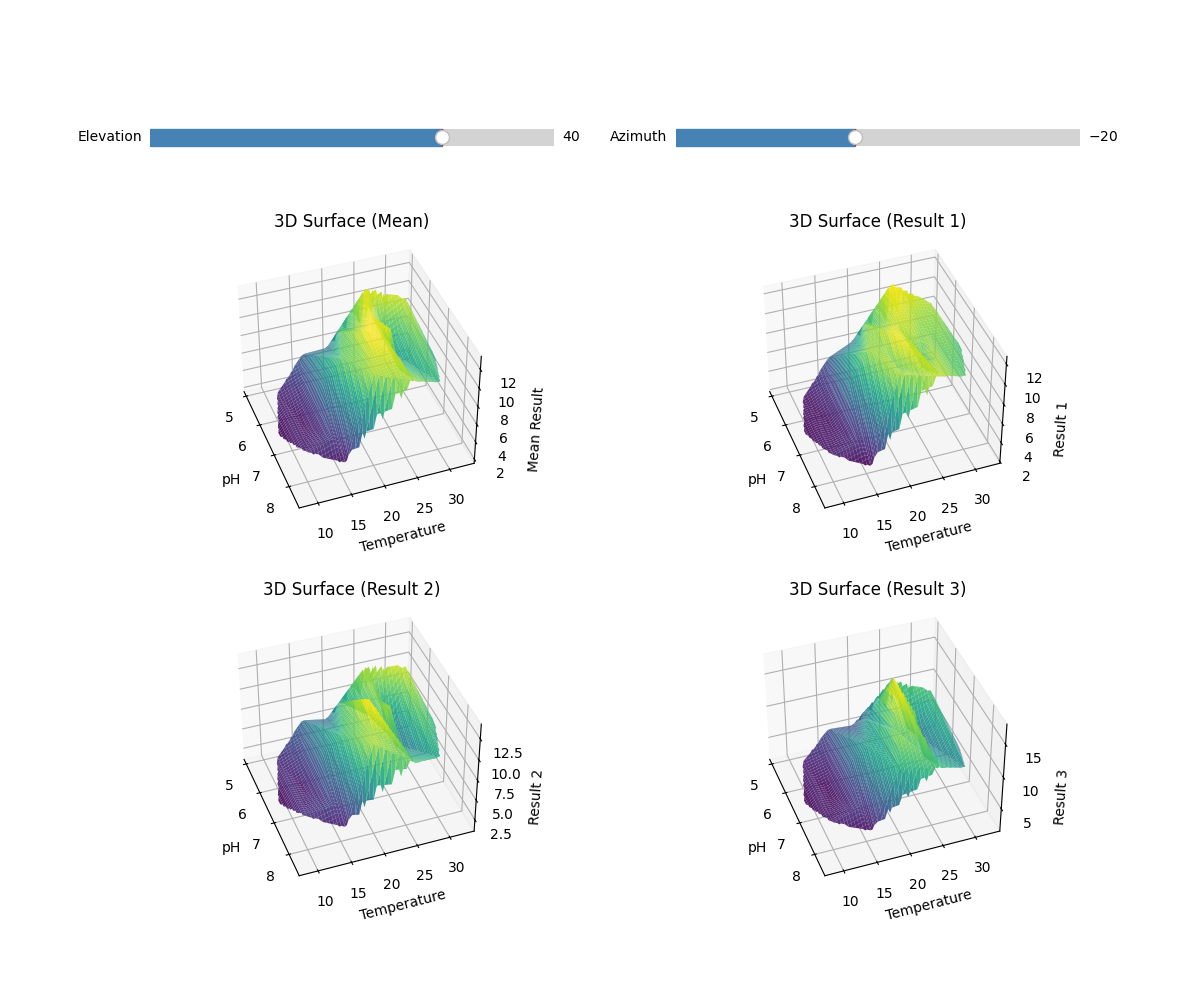

In [9]:
%matplotlib widget

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.widgets import Slider
import numpy as np
from scipy.interpolate import griddata

# ── Interpolationsgitter ──────────────────────────────────────────
x = np.linspace(ph_values.min(),           ph_values.max(),           100)
y = np.linspace(temperatures_values.min(), temperatures_values.max(), 100)
X, Y = np.meshgrid(x, y)

means = [np.mean(v) for v in result]
r1    = [v[0] for v in result]
r2    = [v[1] for v in result]
r3    = [v[2] for v in result]

points = (ph_values, temperatures_values)
Z_grids = [
    griddata(points, vals, (X, Y), method=INTERPOLATION)#'cubic')
    for vals in (means, r1, r2, r3)
]

zlabels     = ['Mean Result', 'Result 1', 'Result 2', 'Result 3']
titles_3d   = [f'3D Surface ({t})' for t in ['Mean', 'Result 1', 'Result 2', 'Result 3']]

# ── Layout: Slider oben, 3D-Plots darunter ───────────────────────
elev_init, azim_init = 40, -20

fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(
    3, 2,
    figure=fig,
    height_ratios=[0.12, 1, 1],
    hspace=0.4,
    wspace=0.3,
)

# ── Slider (Zeile 0, zentriert in Spalten 1 & 2) ─────────────────
ax_elev = fig.add_subplot(gs[0, 0])
ax_azim = fig.add_subplot(gs[0, 1])

slider_elev = Slider(ax_elev, 'Elevation', -90,  90,  valinit=elev_init, valstep=1, color='steelblue')
slider_azim = Slider(ax_azim, 'Azimuth',  -180, 180,  valinit=azim_init, valstep=1, color='steelblue')

# ── 3D-Plots (Zeile 1) ────────────────────────────────────────────
axes_3d = []
for i, (Z, zlabel, title) in enumerate(zip(Z_grids, zlabels, titles_3d)):
    j = 1
    if i > 1:
        j=2
        i-=2
    ax = fig.add_subplot(gs[j, i], projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9)
    ax.set_xlabel('pH',          fontsize=10)
    ax.set_ylabel('Temperature', fontsize=10)
    ax.set_zlabel(zlabel,        fontsize=10)
    ax.set_title(title,          fontsize=12)
    ax.view_init(elev=elev_init, azim=azim_init)
    axes_3d.append(ax)

# ── Callback ──────────────────────────────────────────────────────
def update_view(_):
    for ax in axes_3d:
        ax.view_init(elev=slider_elev.val, azim=slider_azim.val)
    fig.canvas.draw_idle()

slider_elev.on_changed(update_view)
slider_azim.on_changed(update_view)

Path(f"../plots/{FILENAME}").mkdir(parents=True, exist_ok=True)
plt.savefig(f"../plots/{FILENAME}/data_3D_heatmaps.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
import plotly.graph_objects as go
from scipy.interpolate import griddata
import numpy as np

# Ihre Daten interpolieren (wie gehabt)
x = np.linspace(temperatures_values.min(), temperatures_values.max(), 100)
y = np.linspace(ph_values.min(), ph_values.max(), 100)
X, Y = np.meshgrid(x, y)
Z = griddata((temperatures_values, ph_values), [np.mean(x) for x in result], (X, Y), method=INTERPOLATION)

# Interaktiver Plot
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y, colorscale='Viridis')])
fig.update_layout(
    title='Interaktiver 3D Surface Plot',
    scene=dict(
        xaxis_title='Temperatur',
        yaxis_title='pH-Wert',
        zaxis_title='Ergebnis'
    )
)

fig.show()

In [ ]:
import plotly.graph_objects as go
from scipy.interpolate import griddata
import numpy as np

# Ihre Daten interpolieren (wie gehabt)
x = np.linspace(temperatures_values.min(), temperatures_values.max(), 100)
y = np.linspace(ph_values.min(), ph_values.max(), 100)
X, Y = np.meshgrid(x, y)
Z = griddata((temperatures_values, ph_values), [np.mean(x) for x in result], (X, Y), method=INTERPOLATION)#'cubic')

# Interaktiver Plot
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y, colorscale='Viridis')])
fig.update_layout(
    title='Interaktiver 3D Surface Plot',
    scene=dict(
        xaxis_title='Temperatur',
        yaxis_title='pH-Wert',
        zaxis_title='Ergebnis'
    )
)

fig.show()

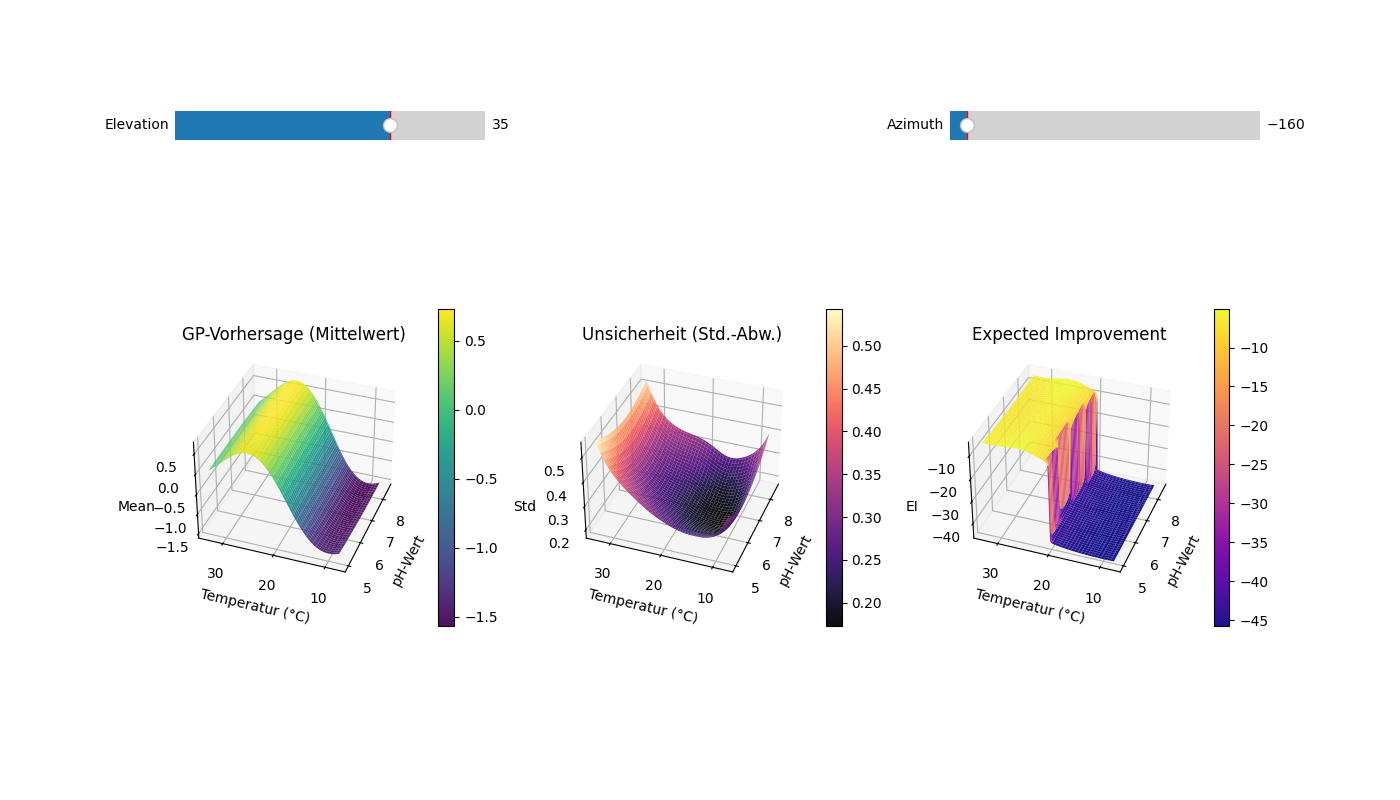

In [11]:
%matplotlib widget

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.widgets import Slider
import numpy as np
from pathlib import Path

# --------------------------------------------------
# Grid für plot_surface
# --------------------------------------------------

PH, TEMP = np.meshgrid(ph_axis, temp_axis)

Z_grids = [
    mean,
    std_dev,
    ei_map
]

titles = [
    "GP-Vorhersage (Mittelwert)",
    "Unsicherheit (Std.-Abw.)",
    "Expected Improvement"
]

zlabels = [
    "Mean",
    "Std",
    "EI"
]

cmaps = [
    "viridis",
    "magma",
    "plasma"
]

# --------------------------------------------------
# Initiale Ansicht
# --------------------------------------------------

elev_init = 35
azim_init = -160

# --------------------------------------------------
# Layout
# --------------------------------------------------

fig = plt.figure(figsize=(14, 8))

gs = gridspec.GridSpec(
    2,
    3,
    figure=fig,
    height_ratios=[0.12, 1],
    hspace=0.25,
    wspace=0.25
)

# --------------------------------------------------
# Slider
# --------------------------------------------------

ax_elev = fig.add_subplot(gs[0, 0])
ax_azim = fig.add_subplot(gs[0, 2])

slider_elev = Slider(
    ax=ax_elev,
    label="Elevation",
    valmin=-90,
    valmax=90,
    valinit=elev_init,
    valstep=1
)

slider_azim = Slider(
    ax=ax_azim,
    label="Azimuth",
    valmin=-180,
    valmax=180,
    valinit=azim_init,
    valstep=1
)

# --------------------------------------------------
# 3D-Plots
# --------------------------------------------------

axes_3d = []

for i, (Z, title, zlabel, cmap) in enumerate(
    zip(Z_grids, titles, zlabels, cmaps)
):

    ax = fig.add_subplot(
        gs[1, i],
        projection="3d"
    )

    surf = ax.plot_surface(
        PH,
        TEMP,
        Z,
        cmap=cmap,
        linewidth=0,
        antialiased=True,
        alpha=0.95
    )

    fig.colorbar(
        surf,
        ax=ax,
        shrink=0.65,
        pad=0.08
    )

    # Messpunkte
    if False:
        ax.scatter(
            train_X_raw[:, 1],
            train_X_raw[:, 0],
            np.full(len(train_X_raw), np.nanmin(Z)),
            c="white",
            edgecolors="black",
            s=40
        )

    ax.set_title(title)

    ax.set_xlabel("pH-Wert")
    ax.set_ylabel("Temperatur (°C)")
    ax.set_zlabel(zlabel)

    ax.view_init(
        elev=elev_init,
        azim=azim_init
    )

    axes_3d.append(ax)

# --------------------------------------------------
# Gemeinsame Rotation
# --------------------------------------------------

def update_view(_):

    for ax in axes_3d:

        ax.view_init(
            elev=slider_elev.val,
            azim=slider_azim.val
        )

    fig.canvas.draw_idle()

slider_elev.on_changed(update_view)
slider_azim.on_changed(update_view)

# --------------------------------------------------
# Speichern
# --------------------------------------------------

Path(f"../plots/{FILENAME}").mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    f"../plots/{FILENAME}/bayes_opt_3d_surfaces.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()